<a href="https://colab.research.google.com/github/Yash49-Xe/first-ML-project--LogisticRegression-/blob/main/Placement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import numpy as np

In [48]:
df = pd.read_csv("/content/sample_data/placement.csv")

In [49]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


**Preprocessing**

In [50]:
df = df.iloc[:,1:]


In [51]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [52]:
df.shape

(100, 3)

**EDA**

In [53]:
import matplotlib.pyplot as plt

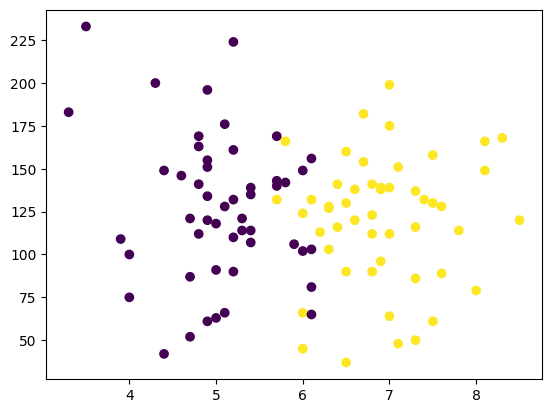

In [54]:
plt.scatter(df['cgpa'],df['iq'],c = df['placement'])

**Seperating Input and Output columns**

In [55]:
X = df.iloc[:,:-1]
Y = df.iloc[:,-1]

In [56]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [57]:
Y.head()

,placement
0,1
1,0
2,0
3,1
4,0


**Train Test Split**

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.1)

In [60]:
X_train

,cgpa,iq
94,4.7,52.0
73,4.9,61.0
16,5.2,224.0
91,7.5,158.0
97,6.7,182.0
...,...,...
72,7.3,116.0
23,4.7,87.0
4,5.8,142.0
62,6.0,102.0


In [61]:
Y_train

,placement
94,0
73,0
16,0
91,1
97,1
...,...
72,1
23,0
4,0
62,0


**Scaling**

In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
scaler = StandardScaler()

In [64]:
X_train = scaler.fit_transform(X_train)

In [65]:
X_train

array([[-1.10013952e+00, -1.77680531e+00],
       [-9.25514203e-01, -1.55140009e+00],
       [-6.63576221e-01,  2.53093881e+00],
       [ 1.34461497e+00,  8.77967228e-01],
       [ 6.46113689e-01,  1.47904780e+00],
       [-7.50888882e-01, -1.42617497e+00],
       [ 1.86849094e+00,  1.07832742e+00],
       [-6.63576221e-01,  2.26796606e-01],
       [ 2.21774158e+00, -7.37436816e-02],
       [-2.32251677e+00,  1.50409283e+00],
       [ 9.95364332e-01,  7.02652060e-01],
       [-6.63576221e-01,  9.53102299e-01],
       [-5.23875964e-02, -4.24374016e-01],
       [-4.88950900e-01,  4.02111773e-01],
       [-2.27012918e-01,  4.27156797e-01],
       [ 1.60655296e+00, -2.24013825e-01],
       [ 1.22237725e-01, -4.99509088e-01],
       [ 5.58801028e-01,  3.77066749e-01],
       [-1.39700257e-01,  1.07832742e+00],
       [-4.88950900e-01, -3.99328993e-01],
       [ 4.71488368e-01, -2.15248067e+00],
       [ 1.43192763e+00, -8.50139423e-01],
       [ 3.49250643e-02,  6.52562012e-01],
       [-1.

In [66]:
X_test = scaler.transform(X_test)

In [67]:
X_test

array([[ 1.25730231,  0.22679661],
       [ 0.90805167,  1.30373263],
       [ 0.12223772, -1.05049961],
       [-0.83820154, -0.12383373],
       [-0.4889509 , -0.22401383],
       [-1.44939017,  1.92985823],
       [ 0.12223772, -1.45122   ],
       [ 0.82073901,  0.40211177],
       [ 0.90805167,  0.40211177],
       [ 1.34461497,  0.17670656]])

**Model Training**

In [68]:
from sklearn.linear_model import LogisticRegression

In [69]:
clf = LogisticRegression()

In [70]:
clf.fit(X_train,Y_train)

LogisticRegression()

**Evatuation**

In [74]:
Y_pred = clf.predict(X_test)

array([1, 1, 1, 0, 0, 0, 1, 1, 1, 1])

In [75]:
from sklearn.metrics import accuracy_score

In [76]:
accuracy = accuracy_score(Y_test,Y_pred)

In [77]:
accuracy

0.8

In [78]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

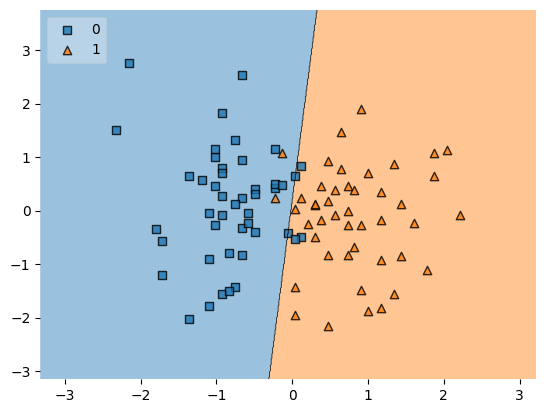

In [81]:
plot_decision_regions(X_train, Y_train.values, clf = clf, legend = 2)